# Movie Review Sentiment Analysis

DLBAIPNLP01 – Project Report

**Author:** Verena Uyka

**Dataset:** NLTK Movie Reviews

## 1. Import Libraries

### Objective

Import the libraries required for data handling, visualization, and access to the NLTK Movie Reviews corpus.

In [ ]:
import matplotlib.pyplot as plt
import nltk
import pandas as pd
from nltk.corpus import movie_reviews

## 2. Download the Dataset

### Objective

Download the NLTK Movie Reviews corpus and make it available in the local Python environment.

In [40]:
nltk.download("movie_reviews")

[nltk_data] Downloading package movie_reviews to
[nltk_data]     /Users/verenauyka/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


True

## 3. Initial Dataset Exploration

### Objective

Inspect the available sentiment categories, determine the total number of reviews, and examine the class distribution.

In [42]:
categories = movie_reviews.categories()
total_reviews = len(movie_reviews.fileids())

print("Categories:", categories)
print("Total number of reviews:", total_reviews)

for category in categories:
    print(f"{category}: {len(movie_reviews.fileids(category))}")

Categories: ['neg', 'pos']
Total number of reviews: 2000
neg: 1000
pos: 1000


### Interpretation

The corpus contains 2,000 English-language movie reviews divided into two sentiment categories: negative and positive. Each category contains exactly 1,000 reviews. The dataset is therefore perfectly balanced, meaning that neither class is overrepresented.

This balanced distribution is advantageous for binary classification because model performance will not be distorted by a dominant class.

## 4. Inspect a Sample Review

### Objective

Examine an individual review to understand the structure and characteristics of the raw textual data.

In [43]:
file_id = movie_reviews.fileids()[0]

print("File:", file_id)
print("Category:", movie_reviews.categories(file_id))
print()
print(movie_reviews.raw(file_id)[:1000])

File: neg/cv000_29416.txt
Category: ['neg']

plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn't snag this one correctly . 
they seem to have taken this pretty neat concept , but executed it terribly . 
so what are the problems with the movie ? 
well , its main problem is that it's simply too jumbled . 
it starts off " normal " but then downshifts into this " fantasy " world in w

### Interpretation

The sample review consists of unprocessed natural-language text and includes punctuation, contractions, quotation marks, and informal expressions. The words are already separated by spaces, while the sentiment label is stored separately in the corpus metadata.

Before the text can be used by a machine-learning model, it must be converted into a numerical representation. Additional preprocessing may also be applied to reduce irrelevant variation in the text.

## 5. Convert the Corpus to a DataFrame

### Objective

Convert the NLTK corpus into a pandas DataFrame to support structured exploration, preprocessing, and machine-learning operations.

In [44]:
documents = []

for category in movie_reviews.categories():
    for file_id in movie_reviews.fileids(category):
        review = movie_reviews.raw(file_id)

        documents.append({
            "review": review,
            "sentiment": category
        })

df = pd.DataFrame(documents)

In [45]:
df.head()

,review,sentiment
0,"plot : two teen couples go to a church party ,...",neg
1,the happy bastard's quick movie review \ndamn ...,neg
2,it is movies like these that make a jaded movi...,neg
3,""" quest for camelot "" is warner bros . ' firs...",neg
4,synopsis : a mentally unstable man undergoing ...,neg


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     2000 non-null   str  
 1   sentiment  2000 non-null   str  
dtypes: str(2)
memory usage: 31.4 KB


In [48]:
df["sentiment"].value_counts()

sentiment
neg    1000
pos    1000
Name: count, dtype: int64

### Interpretation

The corpus was successfully converted into a pandas DataFrame containing 2,000 observations and two variables:

- `review`: the raw movie-review text
- `sentiment`: the associated positive or negative class label

Both columns contain 2,000 non-null values. No missing observations are visible at this stage, and the class distribution remains balanced after conversion.

## 6. Data Quality Assessment

### Objective

Check the dataset for missing values and duplicate reviews that could influence preprocessing or model evaluation.

In [49]:
missing_values = df.isnull().sum()
duplicate_reviews = df.duplicated(subset="review").sum()

print("Missing values:")
print(missing_values)

print()
print("Duplicate reviews:", duplicate_reviews)

Missing values:
review       0
sentiment    0
dtype: int64

Duplicate reviews: 0


### Interpretation

The dataset contains no missing values in either the review text or the sentiment labels. Therefore, no observations need to be removed or imputed because of incomplete data.

No duplicate review texts were identified. Each observation can consequently be treated as an independent document during model development and evaluation.

## 7. Review Length Analysis

### Objective

Measure the length of each review and examine how review lengths are distributed across the dataset.

In [50]:
df["word_count"] = df["review"].str.split().str.len()
df["character_count"] = df["review"].str.len()

df.head()

,review,sentiment,word_count,character_count
0,"plot : two teen couples go to a church party ,...",neg,825,4043
1,the happy bastard's quick movie review \ndamn ...,neg,278,1370
2,it is movies like these that make a jaded movi...,neg,547,2848
3,""" quest for camelot "" is warner bros . ' firs...",neg,552,2929
4,synopsis : a mentally unstable man undergoing ...,neg,841,4418


In [51]:
df[["word_count", "character_count"]].describe()

,word_count,character_count
count,2000.00000,2000.000000
mean,746.34050,3893.002000
std,328.42529,1712.425852
min,17.00000,91.000000
25%,526.75000,2737.750000
50%,696.50000,3622.500000
75%,904.00000,4720.250000
max,2678.00000,14957.000000


In [52]:
df.groupby("sentiment")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
neg,1000.0,705.630,296.729759,17.0,510.0,668.5,848.25,2181.0
pos,1000.0,787.051,352.799881,130.0,543.5,731.5,957.25,2678.0


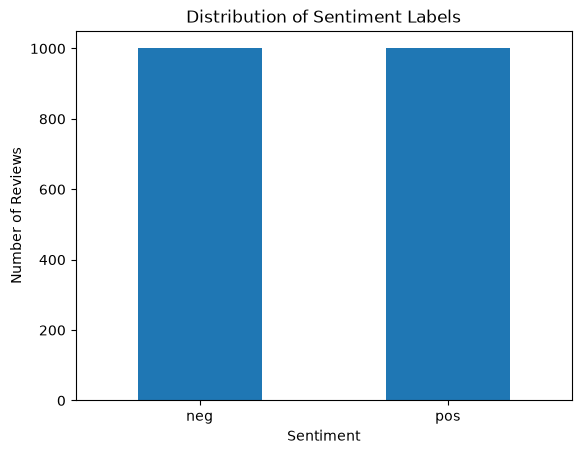

In [53]:
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Distribution of Sentiment Labels")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

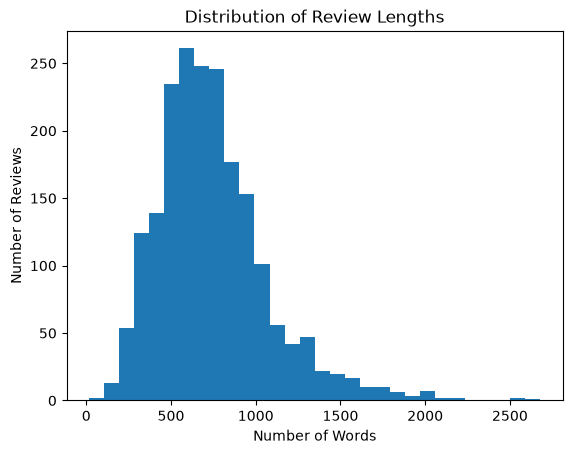

In [54]:
df["word_count"].plot(
    kind="hist",
    bins=30
)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

### Interpretation

The sentiment-distribution plot confirms that the dataset contains equal numbers of positive and negative reviews.

The review-length analysis shows that the documents vary considerably in size. Most reviews fall within a central range, while a smaller number are substantially shorter or longer. This variation is expected in natural-language data and does not prevent the use of TF–IDF vectorization, which can represent documents of different lengths.

The descriptive statistics also allow the review lengths of the positive and negative classes to be compared. Large differences between the classes could potentially become an unintended predictive signal and should therefore be considered during model evaluation.

## 8. Text Preprocessing

### Objective

Transform the raw movie reviews into a cleaner and more standardized textual representation before feature extraction.

The preprocessing pipeline performs the following operations:

1. Convert text to lowercase.
2. Remove non-alphabetic characters.
3. Split the text into individual tokens.
4. Remove common English stop words while retaining sentiment-relevant negations.
5. Reduce words to their base forms through lemmatization.

In [55]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/verenauyka/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/verenauyka/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/verenauyka/nltk_data...


True

In [56]:
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

### Stop-Word Configuration

Common stop words such as articles and prepositions often provide little discriminatory information for text classification. However, negation terms can reverse the meaning of sentiment expressions. Therefore, `no`, `nor`, and `not` are retained.

In [58]:
stop_words = set(stopwords.words("english"))

negation_words = {"no", "nor", "not"}
stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

print("Number of stop words:", len(stop_words))
print("Retained negation words:", negation_words)

Number of stop words: 195
Retained negation words: {'no', 'not', 'nor'}


### Preprocessing Function

The following function applies the selected preprocessing operations consistently to each review.

In [59]:
def preprocess_text(text):
    """
    Clean and normalize a movie review.

    Parameters
    ----------
    text : str
        Raw review text.

    Returns
    -------
    str
        Preprocessed review text.
    """
    text = text.lower()

    tokens = re.findall(r"[a-z]+", text)

    processed_tokens = [
        lemmatizer.lemmatize(token)
        for token in tokens
        if token not in stop_words
    ]

    return " ".join(processed_tokens)

### Test the Preprocessing Function

Before applying the function to the complete dataset, it is tested on a short artificial example and one review from the corpus.

In [61]:
example_text = "The films were not perfect, but the actors were excellent!"

print("Original:")
print(example_text)

print()
print("Preprocessed:")
print(preprocess_text(example_text))

Original:
The films were not perfect, but the actors were excellent!

Preprocessed:
film not perfect actor excellent


In [62]:
sample_review = df.loc[0, "review"]

print("Original review:")
print(sample_review[:500])

print("\nPreprocessed review:")
print(preprocess_text(sample_review)[:500])

Original review:
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt

Preprocessed review:
plot two teen couple go church party drink drive get accident one guy dy girlfriend continues see life nightmare deal watch movie sorta find critique mind fuck movie teen generation touch cool idea present bad package make review even harder one write since generally applaud film attempt break mold mess head lost highway memento good bad way making type film folk snag one correctly seem taken pretty neat concept executed terribly problem movie well main pr

### Apply Preprocessing to the Dataset

The preprocessing function is now applied to all 2,000 movie reviews. The original text is retained so that the raw and processed versions can be compared.

In [63]:
df["processed_review"] = df["review"].apply(preprocess_text)

In [64]:
df[["review", "processed_review", "sentiment"]].head()

,review,processed_review,sentiment
0,"plot : two teen couples go to a church party ,...",plot two teen couple go church party drink dri...,neg
1,the happy bastard's quick movie review \ndamn ...,happy bastard quick movie review damn k bug go...,neg
2,it is movies like these that make a jaded movi...,movie like make jaded movie viewer thankful in...,neg
3,""" quest for camelot "" is warner bros . ' firs...",quest camelot warner bros first feature length...,neg
4,synopsis : a mentally unstable man undergoing ...,synopsis mentally unstable man undergoing psyc...,neg


In [65]:
empty_reviews = (df["processed_review"].str.len() == 0).sum()

print("Empty processed reviews:", empty_reviews)

Empty processed reviews: 0


In [66]:
df["processed_word_count"] = (
    df["processed_review"]
    .str.split()
    .str.len()
)

df[
    ["word_count", "processed_word_count"]
].describe()

,word_count,processed_word_count
count,2000.00000,2000.00000
mean,746.34050,355.35900
std,328.42529,153.60619
min,17.00000,7.00000
25%,526.75000,252.00000
50%,696.50000,332.00000
75%,904.00000,429.00000
max,2678.00000,1397.00000


In [67]:
average_original = df["word_count"].mean()
average_processed = df["processed_word_count"].mean()

reduction_percentage = (
    (average_original - average_processed)
    / average_original
    * 100
)

print(f"Average original word count: {average_original:.2f}")
print(f"Average processed word count: {average_processed:.2f}")
print(f"Average reduction: {reduction_percentage:.2f}%")

Average original word count: 746.34
Average processed word count: 355.36
Average reduction: 52.39%


### Interpretation

Preprocessing substantially reduced the average number of tokens per review because punctuation and frequent stop words were removed. Despite this reduction, no processed reviews were empty, indicating that each document retained textual information that can be used for classification.

The original review column remains available for inspection, while the `processed_review` column will be used as the input for feature extraction.

## 9. Train-Test Split

### Objective

Divide the dataset into separate training and test sets so that the model can be trained on one subset and evaluated on previously unseen reviews.

In [68]:
from sklearn.model_selection import train_test_split

In [69]:
X = df["processed_review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [70]:
print("Training reviews:", len(X_train))
print("Test reviews:", len(X_test))

print()
print("Training class distribution:")
print(y_train.value_counts())

print()
print("Test class distribution:")
print(y_test.value_counts())

Training reviews: 1600
Test reviews: 400

Training class distribution:
sentiment
pos    800
neg    800
Name: count, dtype: int64

Test class distribution:
sentiment
neg    200
pos    200
Name: count, dtype: int64


### Interpretation

The dataset was divided into 1,600 training reviews and 400 test reviews. Stratified sampling preserved the equal distribution of positive and negative labels in both subsets.

The test data will remain unseen during model training and will therefore provide an estimate of how well the classifier generalizes to new reviews.

## 10. TF-IDF Feature Extraction

### Objective

Convert the preprocessed text into numerical feature vectors that can be used by a machine-learning classifier.

Term Frequency–Inverse Document Frequency assigns larger weights to terms that are frequent within a particular document but less frequent across the corpus. This reduces the influence of very common words while emphasizing terms that may be more informative for classification.

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [72]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [73]:
print("Training matrix shape:", X_train_tfidf.shape)
print("Test matrix shape:", X_test_tfidf.shape)

Training matrix shape: (1600, 5000)
Test matrix shape: (400, 5000)


In [74]:
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))
print("First 20 features:")
print(feature_names[:20])

Number of features: 5000
First 20 features:
['aaron' 'abandon' 'abandoned' 'ability' 'able' 'aboard' 'abraham'
 'absence' 'absent' 'absolute' 'absolutely' 'absorbing' 'absurd' 'abuse'
 'abusive' 'abyss' 'academy' 'accent' 'accept' 'acceptable']


### Interpretation

The TF-IDF vectorizer transformed the training and test reviews into sparse numerical matrices. Each row represents one review, while each column represents one term from the learned vocabulary.

The vocabulary was limited to 5,000 features to reduce dimensionality and computational complexity. The vectorizer was fitted exclusively on the training data to prevent information leakage from the test set.

## 11. Model Training

### Objective

Train a logistic-regression classifier to predict whether a movie review expresses positive or negative sentiment.

In [75]:
from sklearn.linear_model import LogisticRegression

In [76]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### Interpretation

The logistic-regression classifier was trained using the TF-IDF representation of the 1,600 training reviews.

Logistic regression is suitable for high-dimensional sparse text data and provides a transparent baseline for binary sentiment classification.

## 12. Generate Predictions

### Objective

Apply the trained classifier to the unseen test reviews and generate predicted sentiment labels.

In [79]:
y_pred = model.predict(X_test_tfidf)

In [80]:
prediction_results = pd.DataFrame(
    {
        "actual": y_test.values,
        "predicted": y_pred
    }
)

prediction_results.head(10)

,actual,predicted
0,neg,neg
1,neg,neg
2,pos,pos
3,neg,pos
4,neg,neg
5,pos,pos
6,pos,pos
7,neg,neg
8,neg,neg
9,pos,pos


In [81]:
correct_predictions = (
    prediction_results["actual"]
    == prediction_results["predicted"]
).sum()

print("Correct predictions:", correct_predictions)
print("Total test reviews:", len(prediction_results))

Correct predictions: 333
Total test reviews: 400


## 13. Model Evaluation

### Objective

Evaluate the classifier on the unseen test set using accuracy, precision, recall, F1-score, and a confusion matrix.

In [88]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [89]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8325


In [90]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

         neg     0.8519    0.8050    0.8278       200
         pos     0.8152    0.8600    0.8370       200

    accuracy                         0.8325       400
   macro avg     0.8335    0.8325    0.8324       400
weighted avg     0.8335    0.8325    0.8324       400



### Evaluation Metrics

Accuracy measures the proportion of all test reviews classified correctly.

Precision measures how often a predicted class label is correct.

Recall measures how many reviews belonging to a class are correctly identified.

The F1-score combines precision and recall into a single measure and is particularly useful when evaluating classification performance across classes.

In [91]:
confusion = confusion_matrix(
    y_test,
    y_pred,
    labels=["neg", "pos"]
)

confusion

array([[161,  39],
       [ 28, 172]])

TN:     top-left: negative reviews correctly classified as negative

FP: top-right: negative reviews incorrectly classified as positive

FN: bottom-left: positive reviews incorrectly classified as negative

TP: bottom-right: positive reviews correctly classified as positive

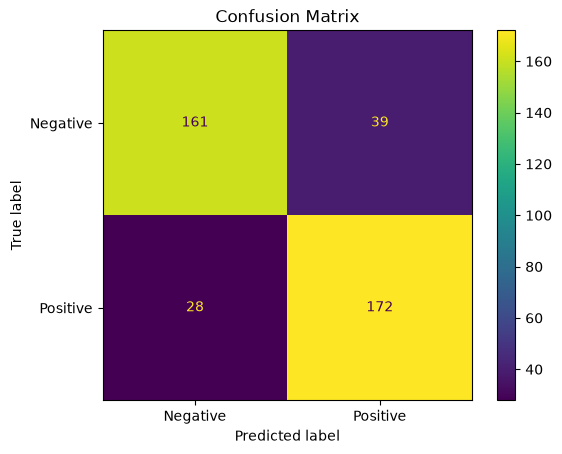

In [92]:
from sklearn.metrics import ConfusionMatrixDisplay

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=["Negative", "Positive"]
)

display.plot()
plt.title("Confusion Matrix")
plt.show()

### Interpretation

The logistic-regression classifier achieved an **accuracy of 83.25%** on the unseen test dataset. This indicates that the model correctly classified approximately four out of every five movie reviews.

The precision, recall, and F1-scores are relatively similar for both sentiment classes, suggesting that the classifier performs consistently across positive and negative reviews without exhibiting a substantial bias toward either class.

The confusion matrix further illustrates the model's performance:

- **161** negative reviews were correctly classified as negative.
- **39** negative reviews were incorrectly classified as positive.
- **28** positive reviews were incorrectly classified as negative.
- **172** positive reviews were correctly classified as positive.

The slightly higher recall for positive reviews (0.86) compared with negative reviews (0.81) indicates that the classifier identifies positive sentiment somewhat more reliably. Conversely, negative reviews are predicted with slightly higher precision (0.85), meaning that reviews classified as negative are somewhat more likely to be truly negative.

Overall, the results demonstrate that a classical NLP pipeline based on TF–IDF feature extraction and logistic regression is capable of learning meaningful sentiment-related patterns from movie-review text. Nevertheless, the remaining classification errors suggest that certain reviews contain linguistic characteristics—such as mixed sentiment, irony, sarcasm, or context-dependent expressions—that cannot be fully captured by a bag-of-words representation.

## 14. Baseline Comparison

### Objective

Compare the trained classifier with a simple majority-class baseline to determine whether the model performs substantially better than a trivial prediction strategy.

In [93]:
from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train_tfidf, y_train)

baseline_predictions = baseline_model.predict(
    X_test_tfidf
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Logistic regression accuracy: {accuracy:.4f}")

Baseline accuracy: 0.5000
Logistic regression accuracy: 0.8325


### Interpretation

The majority-class baseline achieved an accuracy of 0.50 because the test set contains equal numbers of positive and negative reviews.

The logistic-regression model substantially outperformed this baseline, demonstrating that it learned predictive patterns from the review text rather than relying on the class distribution alone.

## 15. Inspect Individual Predictions

### Objective

Examine selected correct and incorrect predictions to better understand the classifier's behavior and limitations.

In [94]:
results = pd.DataFrame(
    {
        "review": X_test.values,
        "actual": y_test.values,
        "predicted": y_pred
    }
)

results["correct"] = (
    results["actual"]
    == results["predicted"]
)

results.head()

,review,actual,predicted,correct
0,dr dolittle th century fox running time hour m...,neg,neg,True
1,spawn feature good guy bad guy lot fighting bl...,neg,neg,True
2,keen wisdom elderly bank robber naive ambition...,pos,pos,True
3,running time approximately hr min reviewed jac...,neg,pos,False
4,one point movie staging opera go completely wr...,neg,neg,True


In [95]:
results[results["correct"]].head(3)

,review,actual,predicted,correct
0,dr dolittle th century fox running time hour m...,neg,neg,True
1,spawn feature good guy bad guy lot fighting bl...,neg,neg,True
2,keen wisdom elderly bank robber naive ambition...,pos,pos,True


In [96]:
results[~results["correct"]].head(3)

,review,actual,predicted,correct
3,running time approximately hr min reviewed jac...,neg,pos,False
10,line duty critically praised series television...,neg,pos,False
14,according popular film opinion film greatness ...,neg,pos,False


### Interpretation

Inspection of individual errors provides information that aggregate metrics cannot show. Some reviews may contain mixed evaluations, indirect language, unusual vocabulary, or sentiment that depends on longer-range context.

Because the model represents reviews primarily through weighted word frequencies, it cannot fully model word order, irony, sarcasm, or complex semantic relationships. These limitations help explain why some reviews are misclassified despite the model's overall performance.

## 16. Interactive Sentiment Prediction

### Objective

Develop a simple prediction function that allows users to enter their own movie reviews and receive an estimated sentiment classification using the trained machine-learning model.

In [97]:
def predict_sentiment(review):
    """
    Predict the sentiment of a movie review.

    Parameters
    ----------
    review : str
        Raw movie review.

    Returns
    -------
    str
        Predicted sentiment label.
    """

    processed_review = preprocess_text(review)

    review_vector = tfidf.transform([processed_review])

    prediction = model.predict(review_vector)[0]

    return prediction

In [98]:
example_review = """
The acting was outstanding, the characters were believable,
and I enjoyed every minute of the movie.
"""

prediction = predict_sentiment(example_review)

print("Prediction:", prediction)

Prediction: pos


In [100]:
example_review = """
This was one of the most boring films I have ever seen.
The story was confusing and the acting was terrible.
"""

prediction = predict_sentiment(example_review)

print("Prediction:", prediction)

Prediction: neg


In [101]:
user_review = input("Enter your movie review:\n\n")

prediction = predict_sentiment(user_review)

print()
print("Predicted sentiment:", prediction)


Predicted sentiment: pos


### Interpretation

The interactive prediction function demonstrates that the trained sentiment-analysis pipeline can be applied to previously unseen reviews entered by a user.

The prediction process follows the same sequence as during model development:

1. preprocessing,
2. TF–IDF feature extraction,
3. logistic-regression classification.

This simple interface illustrates how a trained machine-learning model can be integrated into an application while maintaining a consistent preprocessing workflow.